# Experiment 2 — YOLO11n Instance Segmentation with Dice Loss

## Objective

This experiment evaluates whether replacing the default BCE-based segmentation loss with **Dice Loss** can improve the segmentation performance of the inventory recognition model.

The original model was trained using:

- Model: YOLO11n-Seg
- Dataset: Original AIIC inventory dataset
- Number of classes: 109
- Image size: 640 × 640
- Epochs: 100
- Batch size: 8
- Patience: 20
- Segmentation loss: Binary Cross-Entropy (BCE)

For this experiment, all major training settings will remain the same to ensure a fair comparison.

The main change is:

**BCE Segmentation Loss → Dice Segmentation Loss**

The final Dice model will later be evaluated using the same test dataset and compared with the original BCE model using:

- Precision
- Recall
- Mask mAP@50
- Mask mAP@50–95
- Validation loss

## 1. Setup and Environment Check

This section prepares the environment for the Dice Loss training experiment.

The purpose of this step is to:

- Import the required libraries such as PyTorch and Ultralytics.
- Define the project, dataset, and training output paths.
- Check the installed Ultralytics and PyTorch versions.
- Verify that CUDA is available for GPU training.
- Confirm that the correct dataset configuration file (`data.yaml`) can be found.

No model training is performed in this step. This is only an environment and path verification before modifying the YOLO segmentation loss function.

In [1]:
# ============================================================
# CELL 1 — SETUP & ENVIRONMENT CHECK
# ============================================================

from pathlib import Path
import torch
import ultralytics
from ultralytics import YOLO

project_path = Path(r"G:\AIIC")

segmentation_project = (
    project_path
    / "yolo_segmentation"
)

data_yaml = (
    segmentation_project
    / "dataset"
    / "data.yaml"
)

runs_path = (
    segmentation_project
    / "runs"
)

print("=" * 70)
print("DICE LOSS EXPERIMENT — ENVIRONMENT CHECK")
print("=" * 70)

print(f"Ultralytics version : {ultralytics.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print()
print(f"Project path        : {project_path}")
print(f"Dataset YAML        : {data_yaml}")
print(f"Dataset YAML exists : {data_yaml.exists()}")
print(f"Runs folder         : {runs_path}")

print("=" * 70)

DICE LOSS EXPERIMENT — ENVIRONMENT CHECK
Ultralytics version : 8.4.137
PyTorch version     : 2.13.0+cu130
CUDA available      : True
GPU                 : NVIDIA GeForce RTX 5060

Project path        : G:\AIIC
Dataset YAML        : G:\AIIC\yolo_segmentation\dataset\data.yaml
Dataset YAML exists : True
Runs folder         : G:\AIIC\yolo_segmentation\runs


## 2. Inspect the Current YOLO Segmentation Loss

Before replacing the segmentation loss with Dice Loss, the existing YOLO11 segmentation loss implementation must first be inspected.

This step is important because different Ultralytics versions may implement the segmentation loss differently.

The purpose of this section is to:

- Locate the current YOLO instance segmentation loss function.
- Confirm that the current mask loss uses Binary Cross-Entropy (BCE).
- Identify the exact function signature that must be preserved when replacing BCE with Dice Loss.

No training is performed in this step.

In [2]:
# ============================================================
# CELL 2 — INSPECT CURRENT YOLO SEGMENTATION LOSS
# ============================================================

import inspect

from ultralytics.utils.loss import v8SegmentationLoss

print("=" * 70)
print("CURRENT YOLO INSTANCE SEGMENTATION LOSS FUNCTION")
print("=" * 70)

# Get the source code of the current mask loss function
mask_loss_source = inspect.getsource(
    v8SegmentationLoss.single_mask_loss
)

print(mask_loss_source)

print("=" * 70)

# Simple automatic check
if "binary_cross_entropy" in mask_loss_source.lower():
    print("✅ BCE-based instance mask loss detected.")
else:
    print("⚠️ BCE was not detected automatically.")
    print("Please inspect the function above manually.")

CURRENT YOLO INSTANCE SEGMENTATION LOSS FUNCTION
    @staticmethod
    def single_mask_loss(
        gt_mask: torch.Tensor, pred: torch.Tensor, proto: torch.Tensor, xyxy: torch.Tensor, area: torch.Tensor
    ) -> torch.Tensor:
        """Compute the instance segmentation loss for a single image.

        Args:
            gt_mask (torch.Tensor): Ground truth mask of shape (N, H, W), where N is the number of objects.
            pred (torch.Tensor): Predicted mask coefficients of shape (N, 32).
            proto (torch.Tensor): Prototype masks of shape (32, H, W).
            xyxy (torch.Tensor): Ground truth bounding boxes in xyxy format, normalized to [0, 1], of shape (N, 4).
            area (torch.Tensor): Area of each ground truth bounding box of shape (N,).

        Returns:
            (torch.Tensor): The calculated mask loss for a single image.

        Notes:
            The function uses the equation pred_mask = torch.einsum('in,nhw->ihw', pred, proto) to produce the
         

## 3. Replace BCE Mask Loss with Dice Loss

The default YOLO11 instance segmentation model uses **Binary Cross-Entropy (BCE) with logits** for the instance mask loss.

In this experiment, only the segmentation mask loss is replaced with **Dice Loss**.

The other YOLO loss components remain unchanged:

- Bounding box loss — unchanged
- Classification loss — unchanged
- Distribution Focal Loss (DFL) — unchanged
- Segmentation mask loss — changed from BCE to Dice Loss

Dice Loss measures the overlap between the predicted mask and the ground-truth mask.

The Dice coefficient is defined as:

\[
Dice = \frac{2|P \cap G| + \epsilon}{|P| + |G| + \epsilon}
\]

where:

- \(P\) = predicted segmentation mask
- \(G\) = ground-truth segmentation mask
- \(\epsilon\) = small constant for numerical stability

The Dice Loss is:

\[
L_{Dice} = 1 - Dice
\]

A lower Dice Loss indicates greater overlap between the predicted and ground-truth masks.

This experiment uses **pure Dice Loss**, not a combination of BCE and Dice Loss.

### Implementation Note

The initial Dice Loss implementation applied `crop_mask()` directly to the predicted mask probabilities produced by the sigmoid function.

Ultralytics' `crop_mask()` performs an in-place operation. This modified a tensor required by PyTorch for gradient computation and caused an autograd error during backpropagation.

To solve this, the bounding-box crop region is generated separately using a tensor of ones. The predicted and ground-truth masks are then multiplied by this crop region without modifying the sigmoid output in-place.

This preserves the computation graph required for backpropagation.

In [3]:
# ============================================================
# CELL 3 — REPLACE BCE MASK LOSS WITH PURE DICE LOSS
# AUTOGRAD-SAFE VERSION
# ============================================================

import torch

from ultralytics.utils.loss import v8SegmentationLoss
from ultralytics.utils.ops import crop_mask


# ------------------------------------------------------------
# SAVE ORIGINAL BCE LOSS
# ------------------------------------------------------------

if not hasattr(v8SegmentationLoss, "_original_single_mask_loss"):
    v8SegmentationLoss._original_single_mask_loss = (
        v8SegmentationLoss.single_mask_loss
    )


# ------------------------------------------------------------
# PURE DICE MASK LOSS
# ------------------------------------------------------------

def dice_single_mask_loss(
    gt_mask: torch.Tensor,
    pred: torch.Tensor,
    proto: torch.Tensor,
    xyxy: torch.Tensor,
    area: torch.Tensor
) -> torch.Tensor:

    """
    Compute Pure Dice Loss for YOLO11 instance segmentation.

    This function replaces only the instance mask loss.
    Bounding box, classification and DFL losses remain unchanged.
    """

    # --------------------------------------------------------
    # 1. BUILD PREDICTED MASK LOGITS
    # --------------------------------------------------------

    pred_mask = torch.einsum(
        "in,nhw->ihw",
        pred,
        proto
    )

    # Convert logits to probabilities
    pred_prob = pred_mask.float().sigmoid()

    # Ensure GT mask is float
    gt_mask = gt_mask.float()


    # --------------------------------------------------------
    # 2. CREATE BOUNDING-BOX CROP REGION
    # --------------------------------------------------------
    #
    # We do NOT apply crop_mask() directly to pred_prob.
    # crop_mask() uses in-place modification, which can break
    # PyTorch autograd when applied to sigmoid output.
    #
    # Instead, create a separate crop region using ones.
    # --------------------------------------------------------

    crop_region = torch.ones_like(pred_prob)

    crop_region = crop_mask(
        crop_region,
        xyxy
    )


    # --------------------------------------------------------
    # 3. APPLY CROP WITHOUT IN-PLACE MODIFICATION
    # --------------------------------------------------------

    pred_crop = pred_prob * crop_region
    gt_crop = gt_mask * crop_region


    # --------------------------------------------------------
    # 4. CALCULATE DICE COEFFICIENT
    # --------------------------------------------------------

    intersection = (
        pred_crop * gt_crop
    ).sum(dim=(1, 2))

    pred_sum = pred_crop.sum(dim=(1, 2))
    gt_sum = gt_crop.sum(dim=(1, 2))

    eps = 1e-7

    dice_score = (
        2.0 * intersection + eps
    ) / (
        pred_sum + gt_sum + eps
    )


    # --------------------------------------------------------
    # 5. CALCULATE DICE LOSS
    # --------------------------------------------------------

    dice_loss = 1.0 - dice_score

    # Sum loss across all instances in the image
    return dice_loss.sum()


# ------------------------------------------------------------
# APPLY CUSTOM DICE LOSS
# ------------------------------------------------------------

v8SegmentationLoss.single_mask_loss = staticmethod(
    dice_single_mask_loss
)


# ------------------------------------------------------------
# CONFIRMATION
# ------------------------------------------------------------

print("=" * 70)
print("CUSTOM SEGMENTATION LOSS ACTIVATED")
print("=" * 70)

print("Original mask loss : BCEWithLogits")
print("New mask loss      : Pure Dice Loss")

print()
print("Box loss           : unchanged")
print("Classification loss: unchanged")
print("DFL loss           : unchanged")

print("=" * 70)
print("✅ AUTOGRAD-SAFE PURE DICE LOSS ACTIVATED")

CUSTOM SEGMENTATION LOSS ACTIVATED
Original mask loss : BCEWithLogits
New mask loss      : Pure Dice Loss

Box loss           : unchanged
Classification loss: unchanged
DFL loss           : unchanged
✅ AUTOGRAD-SAFE PURE DICE LOSS ACTIVATED


## 4. Verify the Custom Dice Loss

Before starting the training process, the active segmentation loss function is verified.

This step ensures that:

- The YOLO instance segmentation model is using the custom Dice Loss function.
- The original BCE mask loss is no longer active for the segmentation component.
- The modification only affects the instance mask loss.

This verification is important because the training experiment must genuinely use Dice Loss before it can be compared with the original BCE baseline.

In [4]:
# ============================================================
# CELL 4 — VERIFY ACTIVE SEGMENTATION LOSS
# ============================================================

from ultralytics.utils.loss import v8SegmentationLoss

active_loss = v8SegmentationLoss.single_mask_loss

print("=" * 70)
print("ACTIVE SEGMENTATION LOSS VERIFICATION")
print("=" * 70)

print(f"Active function name : {active_loss.__name__}")

# Check functions referenced inside the active loss
function_names = active_loss.__code__.co_names

uses_bce = "binary_cross_entropy_with_logits" in function_names
uses_dice_function = active_loss.__name__ == "dice_single_mask_loss"

print(f"BCE function detected : {uses_bce}")
print(f"Dice function active  : {uses_dice_function}")

print("=" * 70)

if uses_dice_function and not uses_bce:
    print("✅ VERIFIED: PURE DICE LOSS IS ACTIVE")
    print("✅ BCE mask loss is NOT being used")
else:
    print("❌ VERIFICATION FAILED")
    print("Do NOT start training yet.")

ACTIVE SEGMENTATION LOSS VERIFICATION
Active function name : dice_single_mask_loss
BCE function detected : False
Dice function active  : True
✅ VERIFIED: PURE DICE LOSS IS ACTIVE
✅ BCE mask loss is NOT being used


## 5. Calculate Class Weights from the Training Set

Class weighting is added to reduce the effect of class imbalance across the 109 inventory classes.

The class weights are calculated using only the training labels.

Classes with fewer training instances receive higher weights, while classes with more training instances receive lower weights.

A softened inverse-frequency weighting method is used:

\[
w_c = \frac{1}{\sqrt{n_c}}
\]

The weights are then normalized so that the average class weight is approximately 1.

This modification will only affect the classification loss. The Pure Dice segmentation loss, bounding-box loss, and DFL remain unchanged.

In [5]:
# ============================================================
# CELL 5 — CALCULATE CLASS WEIGHTS
# TRAINING SET ONLY
# ============================================================

import numpy as np
import torch
import yaml

train_labels_path = (
    segmentation_project
    / "dataset"
    / "labels"
    / "train"
)

# Load class names
with open(data_yaml, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

class_names = dataset_config["names"]

if isinstance(class_names, dict):
    class_names = [
        class_names[i]
        for i in sorted(class_names, key=lambda x: int(x))
    ]

num_classes = len(class_names)

# Count instances per class
class_counts = np.zeros(
    num_classes,
    dtype=np.int64
)

for label_file in train_labels_path.glob("*.txt"):

    with open(label_file, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            class_id = int(float(line.split()[0]))

            class_counts[class_id] += 1

# Prevent division by zero
safe_counts = np.maximum(
    class_counts,
    1
)

# Softened inverse-frequency weighting
class_weights_np = (
    1.0
    / np.sqrt(safe_counts.astype(np.float32))
)

# Normalize mean weight to 1
class_weights_np = (
    class_weights_np
    / class_weights_np.mean()
)

CLASS_WEIGHTS = torch.tensor(
    class_weights_np,
    dtype=torch.float32
)

print("=" * 70)
print("CLASS WEIGHT SUMMARY")
print("=" * 70)

print("Number of classes       :", num_classes)
print("Total training instances:", int(class_counts.sum()))
print("Minimum class instances :", int(class_counts.min()))
print("Maximum class instances :", int(class_counts.max()))
print("Minimum class weight    :", round(float(CLASS_WEIGHTS.min()), 4))
print("Maximum class weight    :", round(float(CLASS_WEIGHTS.max()), 4))
print("Average class weight    :", round(float(CLASS_WEIGHTS.mean()), 4))

print("=" * 70)

CLASS WEIGHT SUMMARY
Number of classes       : 109
Total training instances: 4355
Minimum class instances : 0
Maximum class instances : 161
Minimum class weight    : 0.4018
Maximum class weight    : 5.0978
Average class weight    : 1.0


### Check Classes with Zero Training Instances

Before applying class weighting, classes with zero training instances must be identified.

A class with no training instances cannot be learned by the model regardless of how large its class weight is.

This check also verifies whether the missing class appears in the validation or test sets.

In [7]:
# ============================================================
# CELL 5 — CALCULATE CLASS WEIGHTS
# TRAINING SET ONLY
# ZERO-INSTANCE CLASSES EXCLUDED
# ============================================================

import numpy as np
import torch
import yaml

train_labels_path = (
    segmentation_project
    / "dataset"
    / "labels"
    / "train"
)

# ------------------------------------------------------------
# LOAD CLASS NAMES
# ------------------------------------------------------------

with open(data_yaml, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

class_names = dataset_config["names"]

if isinstance(class_names, dict):
    class_names = [
        class_names[i]
        for i in sorted(
            class_names,
            key=lambda x: int(x)
        )
    ]

num_classes = len(class_names)

# ------------------------------------------------------------
# COUNT TRAINING INSTANCES
# ------------------------------------------------------------

class_counts = np.zeros(
    num_classes,
    dtype=np.int64
)

for label_file in train_labels_path.glob("*.txt"):

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            class_id = int(
                float(
                    line.split()[0]
                )
            )

            class_counts[class_id] += 1

# ------------------------------------------------------------
# CALCULATE CLASS WEIGHTS
# ------------------------------------------------------------

class_weights_np = np.zeros(
    num_classes,
    dtype=np.float32
)

# Only classes that actually appear in training
active_mask = class_counts > 0

# Softened inverse-frequency weighting
class_weights_np[active_mask] = (
    1.0
    / np.sqrt(
        class_counts[active_mask].astype(
            np.float32
        )
    )
)

# Normalize ACTIVE classes only
class_weights_np[active_mask] = (
    class_weights_np[active_mask]
    / class_weights_np[active_mask].mean()
)

CLASS_WEIGHTS = torch.tensor(
    class_weights_np,
    dtype=torch.float32
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("CLASS WEIGHT SUMMARY")
print("=" * 70)

print("Number of classes       :", num_classes)
print("Active training classes :", int(active_mask.sum()))
print("Zero-instance classes   :", int((~active_mask).sum()))
print("Total training instances:", int(class_counts.sum()))

print(
    "Minimum active instances:",
    int(class_counts[active_mask].min())
)

print(
    "Maximum active instances:",
    int(class_counts[active_mask].max())
)

print(
    "Minimum active weight   :",
    round(
        float(
            CLASS_WEIGHTS[active_mask].min()
        ),
        4
    )
)

print(
    "Maximum active weight   :",
    round(
        float(
            CLASS_WEIGHTS[active_mask].max()
        ),
        4
    )
)

print(
    "Average active weight   :",
    round(
        float(
            CLASS_WEIGHTS[active_mask].mean()
        ),
        4
    )
)

print("=" * 70)

# ------------------------------------------------------------
# ZERO-INSTANCE CLASS
# ------------------------------------------------------------

zero_ids = np.where(
    class_counts == 0
)[0]

for class_id in zero_ids:
    print(
        f"Zero-instance class: "
        f"{class_id} — {class_names[class_id]} "
        f"→ weight = {CLASS_WEIGHTS[class_id].item():.4f}"
    )

CLASS WEIGHT SUMMARY
Number of classes       : 109
Active training classes : 108
Zero-instance classes   : 1
Total training instances: 4355
Minimum active instances: 4
Maximum active instances: 161
Minimum active weight   : 0.4176
Maximum active weight   : 2.6494
Average active weight   : 1.0
Zero-instance class: 96 — T003_Screwdriver → weight = 0.0000


## 6. Apply Class-Weighted Classification Loss

The original YOLO11-Seg classification component uses Binary Cross-Entropy (BCE).

For this experiment, class weighting is applied to the classification loss so that under-represented inventory classes receive a stronger training signal.

The class weights were calculated from the training-set instance distribution using softened inverse-frequency weighting.

Only positive class targets are weighted. Negative class predictions retain their original BCE contribution.

The loss configuration for this experiment is therefore:

- Bounding box loss — unchanged
- Segmentation mask loss — Pure Dice Loss
- Classification loss — Class-Weighted BCE
- Distribution Focal Loss (DFL) — unchanged

In [11]:
# ============================================================
# CELL 6 — APPLY CLASS-WEIGHTED BCE
# CLASSIFICATION LOSS ONLY
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from ultralytics.utils.loss import v8SegmentationLoss


# ------------------------------------------------------------
# CLASS-WEIGHTED BCE
# ------------------------------------------------------------

class ClassWeightedBCE(nn.Module):

    def __init__(self, class_weights):

        super().__init__()

        self.register_buffer(
            "class_weights",
            class_weights.clone().detach().float()
        )

    def forward(
        self,
        pred_scores,
        target_scores
    ):

        # Original YOLO element-wise BCE
        base_loss = (
            F.binary_cross_entropy_with_logits(
                pred_scores,
                target_scores,
                reduction="none"
            )
        )

        # Shape:
        # [1, 1, 109]
        #
        # This broadcasts automatically across:
        # [batch, anchors, classes]
        weights = self.class_weights.to(
            device=base_loss.device,
            dtype=base_loss.dtype
        ).view(
            1,
            1,
            -1
        )

        weighted_loss = (
            base_loss
            * weights
        )

        return weighted_loss


# ------------------------------------------------------------
# SAVE ORIGINAL INITIALIZER
# ------------------------------------------------------------

if not hasattr(
    v8SegmentationLoss,
    "_original_init_before_class_weight"
):

    v8SegmentationLoss._original_init_before_class_weight = (
        v8SegmentationLoss.__init__
    )


# ------------------------------------------------------------
# PATCH SEGMENTATION LOSS INITIALIZER
# ------------------------------------------------------------

def class_weighted_segmentation_init(
    self,
    model,
    *args,
    **kwargs
):

    # Run original YOLO initialization
    v8SegmentationLoss._original_init_before_class_weight(
        self,
        model,
        *args,
        **kwargs
    )

    # Replace ONLY classification BCE
    self.bce = ClassWeightedBCE(
        CLASS_WEIGHTS.to(
            self.device
        )
    )


v8SegmentationLoss.__init__ = (
    class_weighted_segmentation_init
)


print("=" * 70)
print("CLASS WEIGHTING ACTIVATED")
print("=" * 70)

print("Mask loss           : Pure Dice Loss")
print("Classification loss : Class-Weighted BCE")
print("Box loss            : unchanged")
print("DFL loss            : unchanged")

print()

print(
    "Class weight range  :",
    f"{CLASS_WEIGHTS[CLASS_WEIGHTS > 0].min():.4f}",
    "→",
    f"{CLASS_WEIGHTS.max():.4f}"
)

print(
    "Number of weights   :",
    len(CLASS_WEIGHTS)
)

print("=" * 70)

CLASS WEIGHTING ACTIVATED
Mask loss           : Pure Dice Loss
Classification loss : Class-Weighted BCE
Box loss            : unchanged
DFL loss            : unchanged

Class weight range  : 0.4176 → 2.6494
Number of weights   : 109


## 7. Verify Dice Loss and Class-Weighted BCE

Before training, both custom loss modifications are verified.

This ensures that:

- Pure Dice Loss is active for the segmentation mask.
- Class-Weighted BCE is active for classification.
- The model still uses 109 classes.
- The class-weight vector is correctly attached to the classification loss.

Training should only proceed if both custom components are confirmed.

In [12]:
# ============================================================
# CELL 7 — VERIFY CUSTOM LOSS CONFIGURATION
# WITHOUT MANUALLY BUILDING YOLO CRITERION
# ============================================================

from ultralytics.utils.loss import v8SegmentationLoss


print("=" * 70)
print("LOSS CONFIGURATION VERIFICATION")
print("=" * 70)


# ------------------------------------------------------------
# CHECK DICE MASK LOSS
# ------------------------------------------------------------

active_mask_loss = (
    v8SegmentationLoss.single_mask_loss
)

dice_active = (
    active_mask_loss.__name__
    == "dice_single_mask_loss"
)

print(
    "Dice mask loss active       :",
    dice_active
)


# ------------------------------------------------------------
# CHECK PATCHED INITIALIZER
# ------------------------------------------------------------

weighted_init_active = (
    v8SegmentationLoss.__init__.__name__
    == "class_weighted_segmentation_init"
)

print(
    "Weighted BCE patch active   :",
    weighted_init_active
)


# ------------------------------------------------------------
# CHECK CLASS WEIGHTS
# ------------------------------------------------------------

print(
    "Number of class weights     :",
    len(CLASS_WEIGHTS)
)

nonzero_weights = (
    CLASS_WEIGHTS[
        CLASS_WEIGHTS > 0
    ]
)

print(
    "Minimum active class weight :",
    round(
        float(
            nonzero_weights.min()
        ),
        4
    )
)

print(
    "Maximum active class weight :",
    round(
        float(
            nonzero_weights.max()
        ),
        4
    )
)

print(
    "Zero-weight classes         :",
    int(
        (
            CLASS_WEIGHTS == 0
        ).sum()
    )
)


# ------------------------------------------------------------
# TEST WEIGHTED BCE MODULE
# ------------------------------------------------------------

test_loss = ClassWeightedBCE(
    CLASS_WEIGHTS
)

test_pred = torch.zeros(
    (1, 10, 109),
    dtype=torch.float32
)

test_target = torch.zeros_like(
    test_pred
)

test_output = test_loss(
    test_pred,
    test_target
)

shape_ok = (
    test_output.shape
    == test_pred.shape
)

print(
    "Weighted BCE tensor shape OK:",
    shape_ok
)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("=" * 70)

if (
    dice_active
    and weighted_init_active
    and len(CLASS_WEIGHTS) == 109
    and shape_ok
):

    print(
        "✅ CONFIGURATION READY FOR SMOKE TEST"
    )

else:

    print(
        "❌ VERIFICATION FAILED — DO NOT TRAIN"
    )

print("=" * 70)

LOSS CONFIGURATION VERIFICATION
Dice mask loss active       : True
Weighted BCE patch active   : True
Number of class weights     : 109
Minimum active class weight : 0.4176
Maximum active class weight : 2.6494
Zero-weight classes         : 1
Weighted BCE tensor shape OK: True
✅ CONFIGURATION READY FOR SMOKE TEST


## 8. Dice + Class Weight Smoke Test

Before full training, a one-epoch smoke test is performed.

This test verifies that:

- Pure Dice Loss remains active for instance segmentation.
- Class-Weighted BCE is compatible with YOLO11-Seg classification.
- Forward propagation and backpropagation complete successfully.
- GPU training and validation run without errors.

The smoke-test model is only used for technical verification and will not be used as the final model.

In [13]:
# ============================================================
# CELL 8 — DICE + CLASS WEIGHT SMOKE TEST
# 1 EPOCH ONLY
# ============================================================

from ultralytics import YOLO

print("=" * 70)
print("STARTING DICE + CLASS WEIGHT SMOKE TEST")
print("=" * 70)

print("Model        : YOLO11n-Seg")
print("Mask Loss    : Pure Dice Loss")
print("Class Loss   : Class-Weighted BCE")
print("Classes      : 109")
print("Epochs       : 1")
print("Batch Size   : 8")
print("Image Size   : 640")

print("=" * 70)

# ------------------------------------------------------------
# FRESH PRETRAINED MODEL
# ------------------------------------------------------------

smoke_model = YOLO(
    "yolo11n-seg.pt"
)

# ------------------------------------------------------------
# 1-EPOCH SMOKE TEST
# ------------------------------------------------------------

smoke_results = smoke_model.train(
    data=str(data_yaml),

    epochs=1,
    imgsz=640,
    batch=8,

    device=0,
    workers=4,

    patience=20,

    pretrained=True,
    optimizer="auto",

    amp=True,
    cache=False,

    project=str(runs_path),

    name="dice_class_weight_smoke_test",

    exist_ok=True,

    plots=True,
    verbose=True
)

print()
print("=" * 70)
print("✅ DICE + CLASS WEIGHT SMOKE TEST COMPLETED")
print("=" * 70)

STARTING DICE + CLASS WEIGHT SMOKE TEST
Model        : YOLO11n-Seg
Mask Loss    : Pure Dice Loss
Class Loss   : Class-Weighted BCE
Classes      : 109
Epochs       : 1
Batch Size   : 8
Image Size   : 640
New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.137  Python-3.14.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8123MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\AIIC\yolo_segmentation\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.

## 9. Full Training — Pure Dice + Class Weighting

The full model is trained using the same configuration as the previous Pure Dice experiment.

The only additional modification is the use of class-weighted BCE for classification.

This ensures a fair comparison between:

- Pure Dice
- Pure Dice + Class Weighting

All other major training settings remain unchanged.

In [14]:
# ============================================================
# CELL 9 — FULL DICE + CLASS-WEIGHTED TRAINING
# ============================================================

from ultralytics import YOLO

print("=" * 70)
print("FULL DICE + CLASS-WEIGHTED TRAINING")
print("=" * 70)

print("Model        : YOLO11n-Seg")
print("Dataset      : Original AIIC Dataset")
print("Mask Loss    : Pure Dice Loss")
print("Class Loss   : Class-Weighted BCE")
print("Classes      : 109")
print("Epochs       : 100")
print("Batch Size   : 8")
print("Image Size   : 640")
print("Patience     : 20")

print("=" * 70)

# Fresh pretrained model
model_dice_weighted = YOLO(
    "yolo11n-seg.pt"
)

# Full training
dice_weighted_results = model_dice_weighted.train(
    data=str(data_yaml),

    epochs=100,
    imgsz=640,
    batch=8,

    device=0,
    workers=4,

    patience=20,

    pretrained=True,
    optimizer="auto",

    amp=True,
    cache=False,

    project=str(runs_path),

    name="yolo11n_seg_aiic_dice_class_weighted",

    exist_ok=False,

    plots=True,
    verbose=True
)

print()
print("=" * 70)
print("✅ FULL DICE + CLASS-WEIGHTED TRAINING COMPLETED")
print("=" * 70)

FULL DICE + CLASS-WEIGHTED TRAINING
Model        : YOLO11n-Seg
Dataset      : Original AIIC Dataset
Mask Loss    : Pure Dice Loss
Class Loss   : Class-Weighted BCE
Classes      : 109
Epochs       : 100
Batch Size   : 8
Image Size   : 640
Patience     : 20
New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.137  Python-3.14.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8123MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\AIIC\yolo_segmentation\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=

## 10. Evaluate Dice + Class Weight Model on Test Set

The trained Dice + Class Weight model is evaluated using the same held-out test dataset used for the previous Pure Dice experiment.

This ensures a fair comparison because both models are evaluated on the same unseen test images.

The main mask metrics used are:

- Precision
- Recall
- mAP@50
- mAP@50–95

The results will then be compared directly with the Pure Dice model trained without class weighting.

In [15]:
# ============================================================
# CELL 10 — TEST EVALUATION
# DICE + CLASS WEIGHT
# ============================================================

from ultralytics import YOLO

dice_weighted_model_path = (
    runs_path
    / "yolo11n_seg_aiic_dice_class_weighted"
    / "weights"
    / "best.pt"
)

print("=" * 70)
print("DICE + CLASS WEIGHT — TEST EVALUATION")
print("=" * 70)

print("Model path :", dice_weighted_model_path)
print("Exists     :", dice_weighted_model_path.exists())

print("=" * 70)

dice_weighted_model = YOLO(
    str(dice_weighted_model_path)
)

dice_weighted_metrics = dice_weighted_model.val(
    data=str(data_yaml),

    split="test",

    imgsz=640,
    batch=8,

    device=0,
    workers=4,

    project=str(
        segmentation_project
        / "evaluation"
    ),

    name="dice_class_weight_test_evaluation",

    plots=True,
    verbose=True
)

print()
print("=" * 70)
print("✅ TEST EVALUATION COMPLETED")
print("=" * 70)

DICE + CLASS WEIGHT — TEST EVALUATION
Model path : G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic_dice_class_weighted\weights\best.pt
Exists     : True
Ultralytics 8.4.137  Python-3.14.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8123MiB)
YOLO11n-seg summary (fused): 114 layers, 2,902,731 parameters, 0 gradients, 10.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 61.730.5 MB/s, size: 1853.5 KB)
val: Scanning G:\AIIC\yolo_segmentation\dataset\labels\test.cache... 414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 414/414 144.7Mit/s 0.0s
val: G:\AIIC\yolo_segmentation\dataset\images\test\E002_Arduino_Nano__WhatsApp Image 2026-08-11 at 6.07.15 PM (1).jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.4it/s 11.7s0.1ss
                   all        414        900      0.757      0.713      0.756      0.661      0.762      0.712 

## 11. Comparison — Pure Dice vs Dice + Class Weight

The test-set performance of the Pure Dice model is compared with the Dice + Class Weight model.

The purpose of this comparison is to determine whether class weighting improves recognition of the inventory classes without significantly reducing overall segmentation performance.

In [16]:
# ============================================================
# CELL 11 — COMPARE
# PURE DICE VS DICE + CLASS WEIGHT
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# PURE DICE RESULTS — BEFORE CLASS WEIGHT
# ------------------------------------------------------------

dice_before = {
    "Precision": 72.14,
    "Recall": 73.04,
    "mAP50": 75.27,
    "mAP50-95": 63.09
}


# ------------------------------------------------------------
# NEW DICE + CLASS WEIGHT RESULTS
# ------------------------------------------------------------

dice_weighted_after = {
    "Precision": dice_weighted_metrics.seg.mp * 100,
    "Recall": dice_weighted_metrics.seg.mr * 100,
    "mAP50": dice_weighted_metrics.seg.map50 * 100,
    "mAP50-95": dice_weighted_metrics.seg.map * 100
}


# ------------------------------------------------------------
# BUILD COMPARISON TABLE
# ------------------------------------------------------------

comparison_df = pd.DataFrame(
    {
        "Pure Dice": dice_before,
        "Dice + Class Weight": dice_weighted_after
    }
)

comparison_df["Difference"] = (
    comparison_df["Dice + Class Weight"]
    - comparison_df["Pure Dice"]
)

comparison_df = comparison_df.round(2)

print("=" * 70)
print("PURE DICE VS DICE + CLASS WEIGHT")
print("=" * 70)

display(comparison_df)

PURE DICE VS DICE + CLASS WEIGHT


,Pure Dice,Dice + Class Weight,Difference
Precision,72.14,76.19,4.05
Recall,73.04,71.21,-1.83
mAP50,75.27,74.70,-0.57
mAP50-95,63.09,63.07,-0.02


In [17]:
# ============================================================
# CELL 12 — LOSS CURVES
# DICE + CLASS WEIGHT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

results_csv = (
    runs_path
    / "yolo11n_seg_aiic_dice_class_weighted"
    / "results.csv"
)

print("Results CSV:", results_csv)
print("Exists     :", results_csv.exists())

df = pd.read_csv(results_csv)

# Remove accidental spaces in Ultralytics CSV column names
df.columns = df.columns.str.strip()

print("\nAvailable columns:")
print(df.columns.tolist())

Results CSV: G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic_dice_class_weighted\results.csv
Exists     : True

Available columns:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


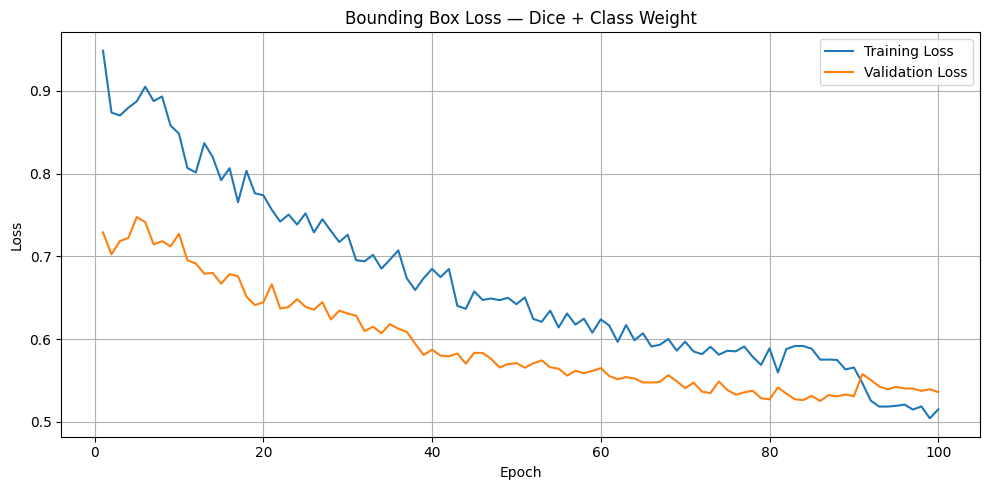

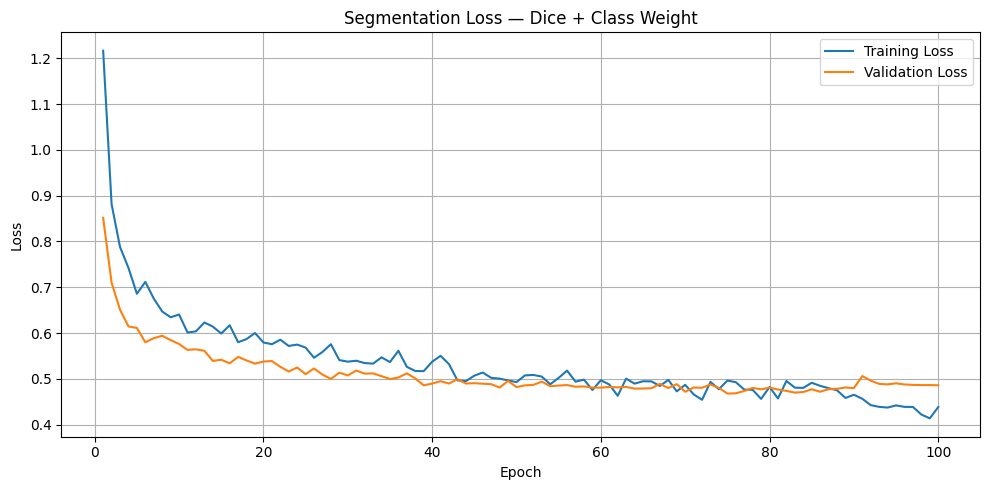

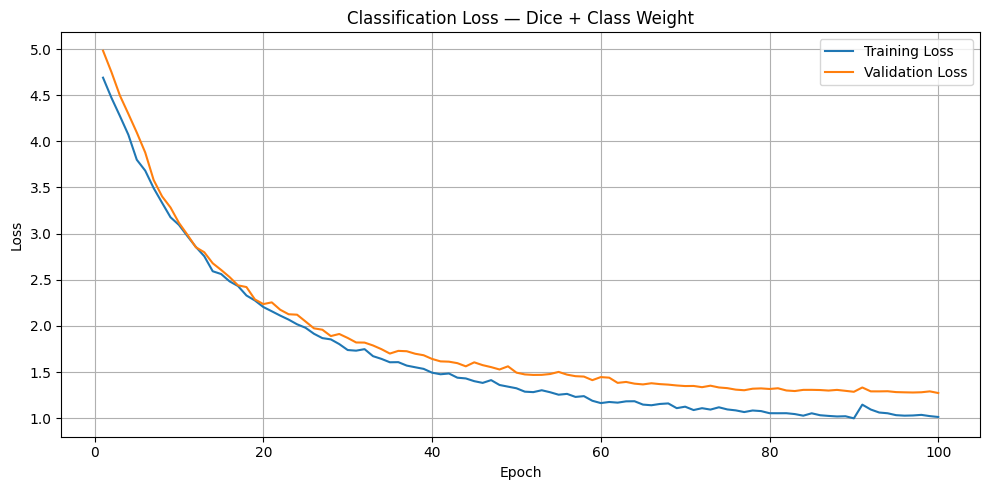

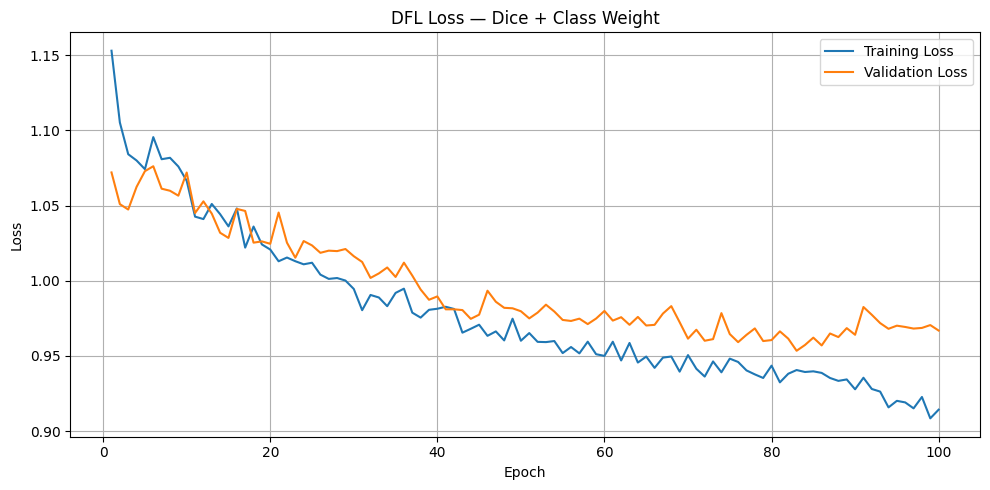

In [18]:
# ============================================================
# PLOT LOSS CURVES
# ============================================================

loss_pairs = [
    ("train/box_loss", "val/box_loss", "Bounding Box Loss"),
    ("train/seg_loss", "val/seg_loss", "Segmentation Loss"),
    ("train/cls_loss", "val/cls_loss", "Classification Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss")
]

for train_col, val_col, title in loss_pairs:

    plt.figure(figsize=(10, 5))

    plt.plot(
        df["epoch"],
        df[train_col],
        label="Training Loss"
    )

    plt.plot(
        df["epoch"],
        df[val_col],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{title} — Dice + Class Weight"
    )

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()